In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import keras

c:\Users\Chabiloo\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## NLTK resources

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chabiloo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Chabiloo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Chabiloo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Chabiloo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# I just directly downloaded the files from the provided URLs and read them into pandas DataFrames.
train_path = keras.utils.get_file(
    "train.csv.zip", 
    "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/train.csv.zip"
)
train_df = pd.read_csv(train_path)

test_path = keras.utils.get_file(
    "test.csv.zip", 
    "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/test.csv.zip"
)
test_df = pd.read_csv(test_path)

## Project 1 - NLP and Text Classification

For this project you will need to classify some angry comments into their respective category of angry. The process that you'll need to follow is (roughly):
<ol>
<li> Use NLP techniques to process the training data. 
<li> Train model(s) to predict which class(es) each comment is in.
    <ul>
    <li> A comment can belong to any number of classes, including none. 
    </ul>
<li> Generate predictions for each of the comments in the test data. 
<li> Write your test data predicitions to a CSV file, which will be scored. 
</ol>

You can use any models and NLP libraries you'd like. 

## Training Data

Use the training data to train your prediction model(s). Each of the classification output columns (toxic to the end) is a human label for the comment_text, assessing if it falls into that category of "rude". A comment may fall into any number of categories, or none at all. Membership in one output category is <b>independent</b> of membership in any of the other classes (think about this when you plan on how to make these predictions - it may also make it easier to split work amongst a team...). 

In [4]:
#train_df = pd.read_csv("train.csv.zip")
train_df.head(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Test Data

In [5]:
#test_df = pd.read_csv("test.csv")
test_df.head()

,id,comment_text
0,1,Yo bitch Ja Rule is more succesful then you'll...
1,2,== From RfC == \n\n The title is fine as it is...
2,3,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,4,":If you have a look back at the source, the in..."
4,5,I don't anonymously edit articles at all.


## Output Details, Submission Info, and Example Submission

For this project, please output your predictions in a CSV file. The structure of the CSV file should match the structure of the example below. 

The output should contain one row for each row of test data, complete with the columns for ID and each classification.

Into Moodle please submit:
<ul>
<li> Your notebook file(s). I'm not going to run them, just look. 
<li> Your sample submission CSV. This will be evaluated for accuracy against the real labels; only a subset of the predictions will be scored. 
</ul>

It is REALLY, REALLY, REALLY important the the structure of your output matches the specifications. The accuracies will be calculated by a script, and it is expecting a specific format. 

### Sample Evaluator

The file prediction_evaluator.ipynb contains an example scoring function, scoreChecker. This function takes a sumbission and an answer key, loops through, and evaluates the accuracy. You can use this to verify the format of your submission. I'm going to use the same function to evaluate the accuracy of your submission, against the answer key (unless I made some mistake in this counting function).

## Tokenizer

In [6]:
stop_words = stopwords.words('english')

class lemmaTokenizer(object):
    def __init__(self, stop_words):
        self.stop_words = stop_words
        self.wnl = WordNetLemmatizer()
    def __call__(self, doc):
        doc = re.sub('[^a-zA-Z]', ' ', doc)
        tokens = nltk.word_tokenize(doc.lower())
        return [self.wnl.lemmatize(t) for t in tokens if t not in self.stop_words]

## Pipeline and Targets

In [7]:
categories = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

pipeline = Pipeline([
                    ("vect", TfidfVectorizer(tokenizer=lemmaTokenizer(stop_words), 
                         max_features=5000, 
                         ngram_range=(1,2))),
                    ("model", LogisticRegression(C=2.0, class_weight='balanced', solver='liblinear'))
])

## Train and Predict

In [8]:
predictions = {'id': test_df['id']}

for category in categories:
    pipeline.fit(train_df['comment_text'], train_df[category])
    predictions[category] = pipeline.predict(test_df['comment_text'])

c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Li

## Grading

The grading for this is split between accuracy and well written code:
<ul>
<li> 75% - Accuracy. The most accurate will get 100% on this, the others will be scaled down from there. 
<li> 25% - Code quality. Can the code be followed and made sense of - i.e. comments, sections, titles. 
</ul>

## F1_score

In [9]:
train_sub, val_sub = train_test_split(train_df, test_size=0.2, random_state=42)

f1_results = {}

for category in categories:
   
    pipeline.fit(train_sub['comment_text'], train_sub[category])
    
    val_preds = pipeline.predict(val_sub['comment_text'])
    
    score = f1_score(val_sub[category], val_preds)
    f1_results[category] = score

c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Chabiloo\anaconda3\Li

## Viz

C:\Users\Chabiloo\AppData\Local\Temp\ipykernel_36032\1184213917.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='F1 Score', y='Category', data=df_viz, palette=pal)


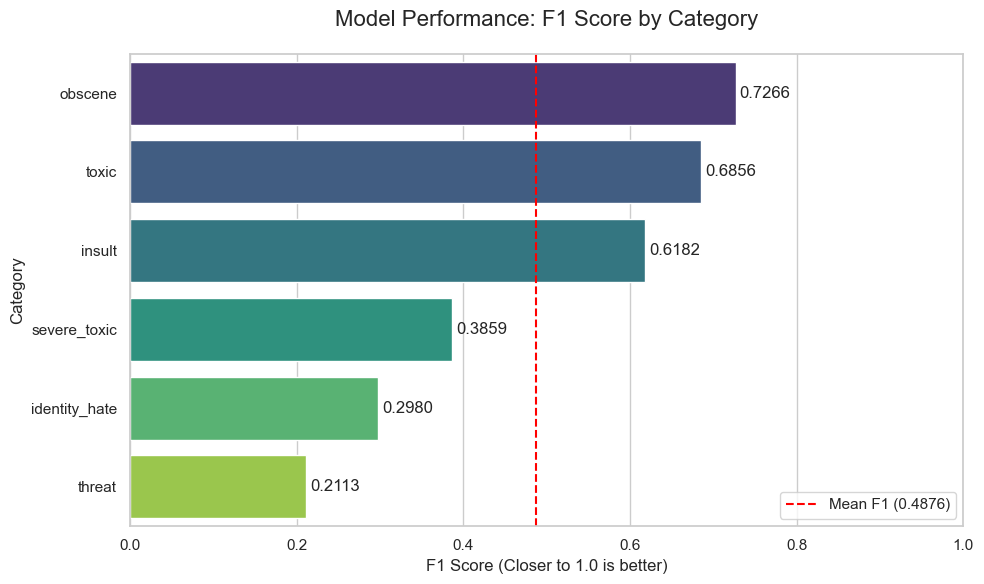

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.DataFrame(list(f1_results.items()), columns=['Category', 'F1 Score'])
df_viz = df_viz.sort_values('F1 Score', ascending=False)

# Visual Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# bar plot
pal = sns.color_palette("viridis", len(df_viz))
ax = sns.barplot(x='F1 Score', y='Category', data=df_viz, palette=pal)

# data labels to the end of each bar
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=3)

# Title and formatting
plt.title('Model Performance: F1 Score by Category', fontsize=16, pad=20)
plt.xlim(0, 1.0) # F1 Score is always between 0 and 1
plt.xlabel('F1 Score (Closer to 1.0 is better)', fontsize=12)
plt.ylabel('Category', fontsize=12)

# vertical line for the Mean F1
mean_f1 = df_viz['F1 Score'].mean()
plt.axvline(mean_f1, color='red', linestyle='--', label=f'Mean F1 ({mean_f1:.4f})')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()